# Bike Rental Demand Prediction
**Goal:** Predict the total number of bike rentals (`cnt`) per hour using weather, time, and calendar features.

**Dataset:** Capital Bikeshare system data (2011–2012), 17,379 hourly records.

## Step 1 — Imports

In [1]:
# Standard data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Show plots inside the notebook (magic command — no inline comments allowed)
%matplotlib inline

## Step 2 — Load Data

In [2]:
# Load the CSV — use raw string (r"") so backslashes in the path don't cause issues
df = pd.read_csv(r"E:\Work_folder (E drive)\ExcelR Projects\Project-1\New folder\Dataset.csv")

print(f"Shape: {df.shape}")   # rows x columns
df.head()                      # preview first 5 rows

Shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


In [3]:
# Check data types — important because some numeric columns may be read as strings
df.dtypes

instant       int64
dteday          str
season          str
yr              str
mnth            str
hr            int64
holiday         str
weekday       int64
workingday      str
weathersit      str
temp            str
atemp           str
hum             str
windspeed       str
casual          str
registered      str
cnt           int64
dtype: object

## Step 3 — Data Cleaning

The dataset uses `?` as a placeholder for missing values. We need to:
1. Replace `?` with `NaN`
2. Convert columns to correct data types
3. Fill missing values
4. Drop any rows that couldn't be filled

In [4]:
# Step 3a — Replace '?' with NaN so pandas treats them as proper missing values
df.replace('?', np.nan, inplace=True)

# Step 3b — Convert numeric columns (they were read as strings because of '?')
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed',
                'casual', 'registered', 'cnt',
                'yr', 'mnth', 'hr', 'weekday', 'instant']

for col in numeric_cols:
    # errors='coerce' turns any non-numeric value into NaN instead of crashing
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 3c — Parse the date column into a proper datetime object
df['dteday'] = pd.to_datetime(df['dteday'], format='%d-%m-%Y')

print("Data types after conversion:")
df.dtypes

Data types after conversion:


instant                int64
dteday        datetime64[us]
season                   str
yr                   float64
mnth                 float64
hr                     int64
holiday                  str
weekday                int64
workingday               str
weathersit               str
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual               float64
registered           float64
cnt                    int64
dtype: object

In [5]:
# Step 3d — Check how many missing values exist in each column
missing = df.isnull().sum()
print("Missing value counts:")
print(missing[missing > 0])
print(f"\nTotal missing cells: {missing.sum()}")

Missing value counts:
season         6
yr             1
mnth           1
holiday        1
workingday     5
weathersit     4
temp          11
atemp          6
hum            6
windspeed      5
casual         1
registered     1
dtype: int64

Total missing cells: 48


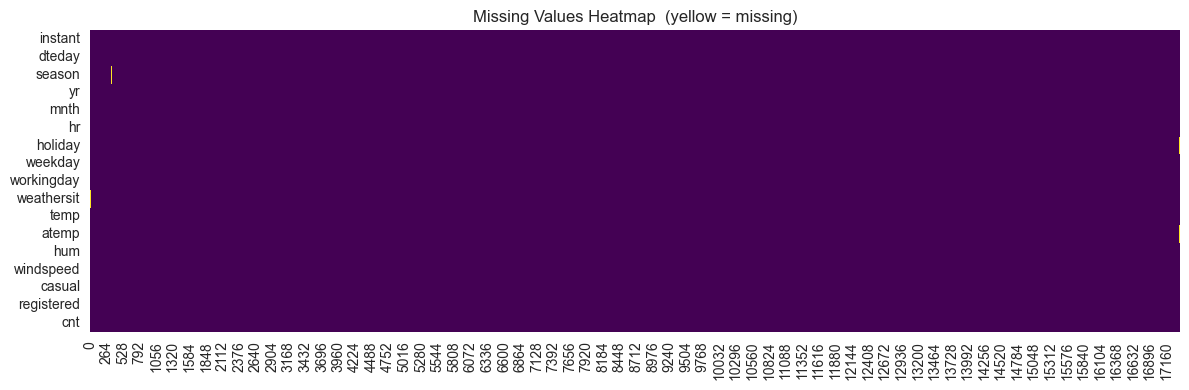

In [6]:
# Visual map of where missing values are located (yellow = missing)
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull().T, cbar=False, cmap='viridis', yticklabels=True)
plt.title('Missing Values Heatmap  (yellow = missing)')
plt.tight_layout()
plt.show()

In [7]:
# Step 3e — Fill missing values
#
# IMPORTANT: We use  df[col] = df[col].fillna(...)  NOT  df[col].fillna(..., inplace=True)
# In modern pandas, inplace=True on a Series view doesn't always update the DataFrame.
# Assignment is the safe and correct way.

# Numeric columns → fill with median (robust to outliers)
for col in ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'yr', 'mnth']:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns → fill with most frequent value (mode)
for col in ['season', 'weathersit', 'holiday', 'workingday']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Drop any remaining rows that couldn't be filled (e.g. 'cnt' with no value)
# Only ~8 rows out of 17,379 — negligible impact
df.dropna(inplace=True)

print(f"Remaining missing values: {df.isnull().sum().sum()}")
print(f"Shape after cleaning:     {df.shape}")

Remaining missing values: 0
Shape after cleaning:     (17379, 17)


In [8]:
# Summary statistics — check ranges and spot any anomalies
print(f"Duplicate rows: {df.duplicated().sum()}")
df.describe().T

Duplicate rows: 0


,count,mean,min,25%,50%,75%,max,std
instant,17379.0,8690.0,1.0,4345.5,8690.0,13034.5,17379.0,5017.0295
dteday,17379,2012-01-02 04:08:34.552045,2011-01-01 00:00:00,2011-07-04 00:00:00,2012-01-02 00:00:00,2012-07-02 00:00:00,2012-12-31 00:00:00,NaN
yr,17379.0,2011.502618,2011.0,2011.0,2012.0,2012.0,2012.0,0.500008
mnth,17379.0,6.537488,1.0,4.0,7.0,10.0,12.0,3.438528
hr,17379.0,11.546752,0.0,6.0,12.0,18.0,23.0,6.914405
weekday,17379.0,3.003683,0.0,1.0,3.0,5.0,6.0,2.005771
temp,17379.0,0.497133,0.02,0.34,0.5,0.66,1.0,0.192464
atemp,17379.0,0.475854,0.0,0.3333,0.4848,0.6212,1.0,0.1718
hum,17379.0,0.627209,0.0,0.48,0.63,0.78,1.0,0.192906
windspeed,17379.0,0.190081,0.0,0.1045,0.194,0.2537,0.8507,0.122303


## Step 4 — Outlier Detection & Treatment

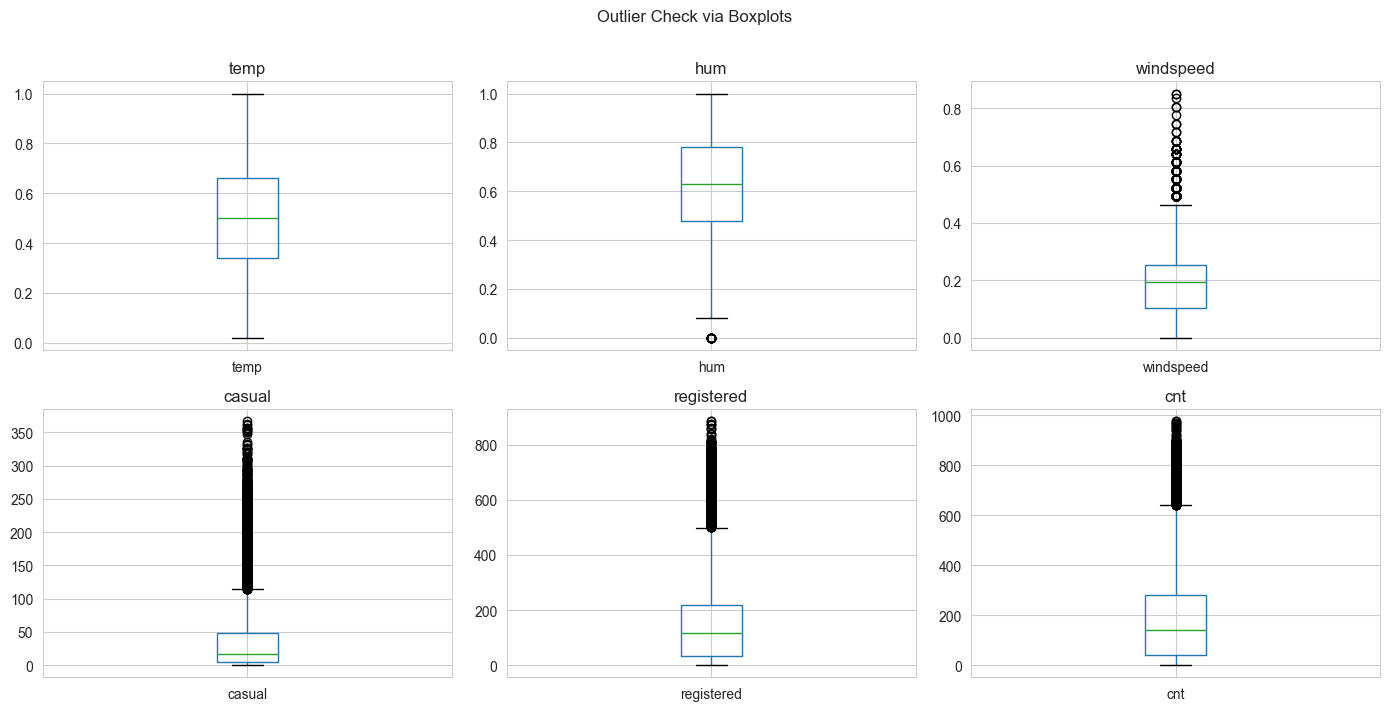

In [9]:
# Boxplots show the spread of each column and highlight extreme outliers
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
box_cols = ['temp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

for i, col in enumerate(box_cols):
    df.boxplot(column=col, ax=axes[i // 3][i % 3])
    axes[i // 3][i % 3].set_title(col)

plt.suptitle('Outlier Check via Boxplots', y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# Windspeed has extreme outliers — cap them using the IQR method
# IQR = Q3 - Q1  →  upper fence = Q3 + 1.5 * IQR
# Values above the fence are capped (not deleted) to preserve row count

Q1 = df['windspeed'].quantile(0.25)
Q3 = df['windspeed'].quantile(0.75)
upper_cap = Q3 + 1.5 * (Q3 - Q1)

df['windspeed'] = df['windspeed'].clip(upper=upper_cap)
print(f"Windspeed capped at: {upper_cap:.4f}")

Windspeed capped at: 0.4775


## Step 5 — Exploratory Data Analysis (EDA)

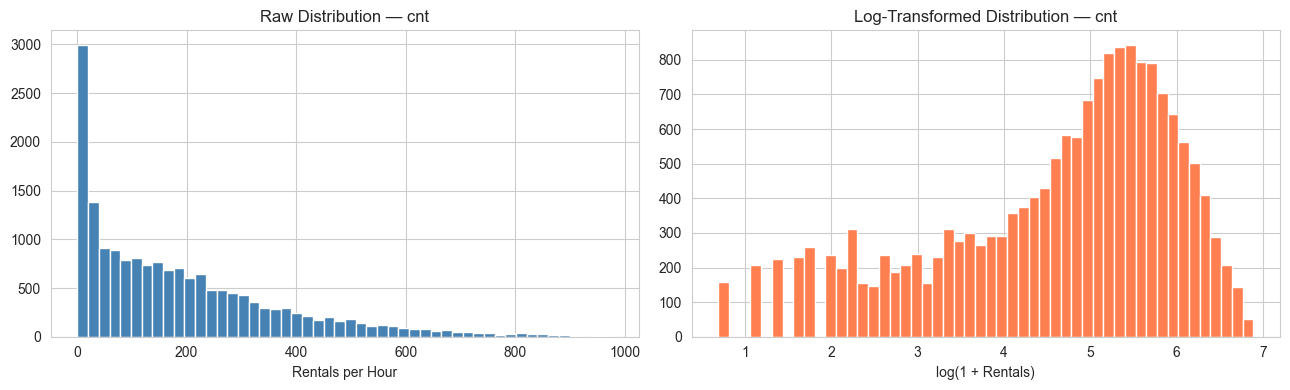

In [11]:
# Distribution of the target variable 'cnt'
# Left plot: raw — right-skewed (most hours have low rentals, few hours have very high)
# Right plot: log transform — more symmetric, better for some models

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['cnt'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Raw Distribution — cnt')
axes[0].set_xlabel('Rentals per Hour')

axes[1].hist(np.log1p(df['cnt']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Log-Transformed Distribution — cnt')
axes[1].set_xlabel('log(1 + Rentals)')

plt.tight_layout()
plt.show()

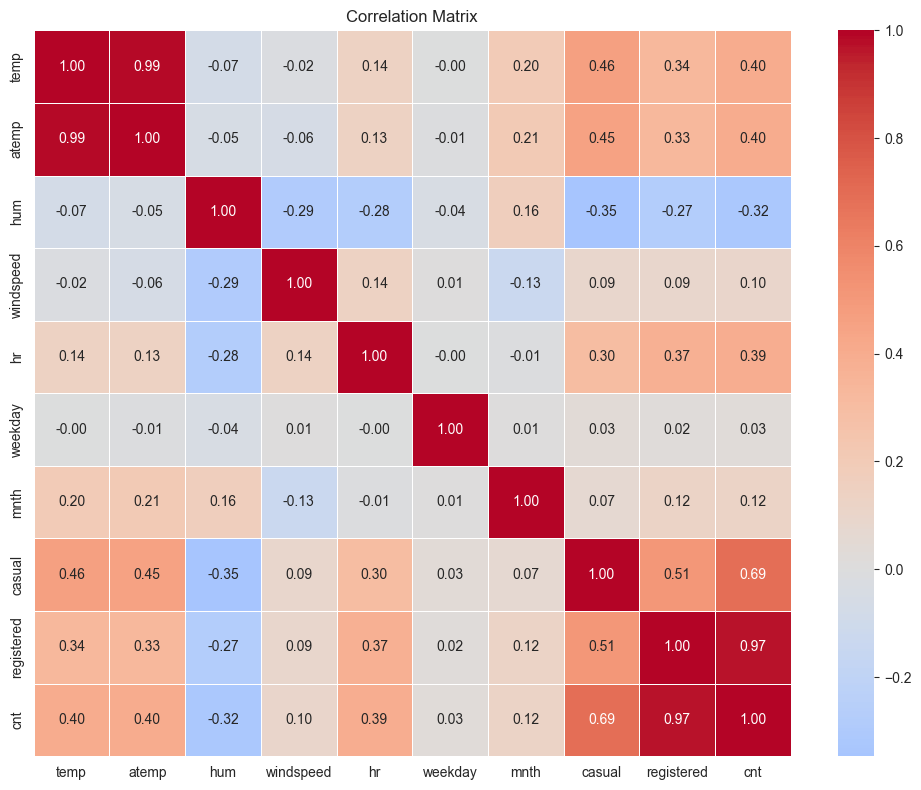

In [12]:
# Correlation matrix — shows how strongly each variable is linearly related to others
# Values close to +1 or -1 = strong relationship; close to 0 = weak relationship

corr_cols = ['temp', 'atemp', 'hum', 'windspeed', 'hr', 'weekday',
             'mnth', 'casual', 'registered', 'cnt']

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

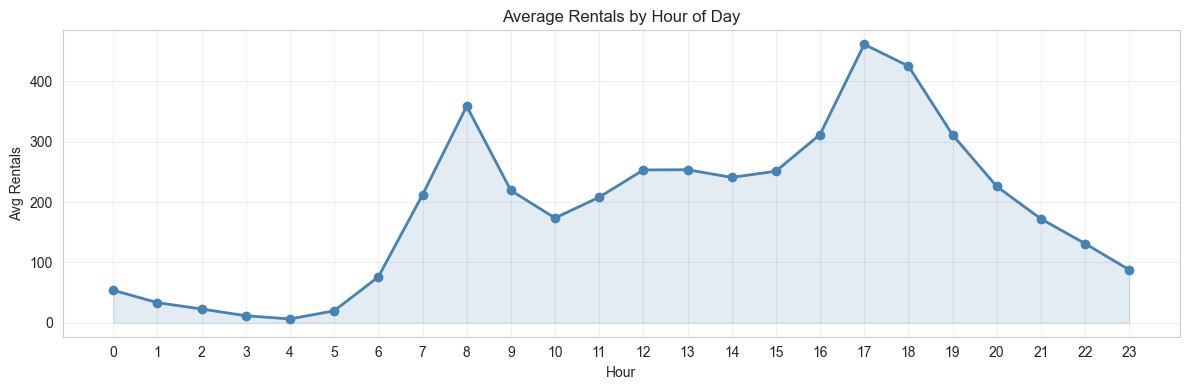

In [13]:
# Average rentals by hour of day
# Expect a double peak on working days (morning & evening commute)

hourly = df.groupby('hr')['cnt'].mean()

plt.figure(figsize=(12, 4))
plt.plot(hourly.index, hourly.values, marker='o', color='steelblue', linewidth=2)
plt.fill_between(hourly.index, hourly.values, alpha=0.15, color='steelblue')
plt.title('Average Rentals by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Rentals')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

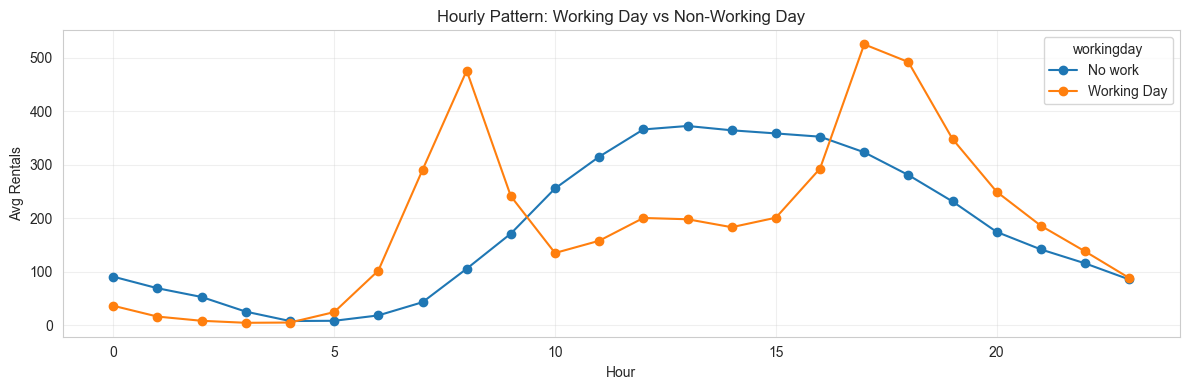

In [14]:
# Compare hourly pattern: working day vs non-working day
# Working days → bimodal peak (commuters)
# Non-working days → single broad midday peak (leisure riders)

fig, ax = plt.subplots(figsize=(12, 4))
for wday in sorted(df['workingday'].unique()):
    subset = df[df['workingday'] == wday].groupby('hr')['cnt'].mean()
    ax.plot(subset.index, subset.values, marker='o', label=str(wday))

ax.set_title('Hourly Pattern: Working Day vs Non-Working Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Avg Rentals')
ax.legend(title='workingday')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

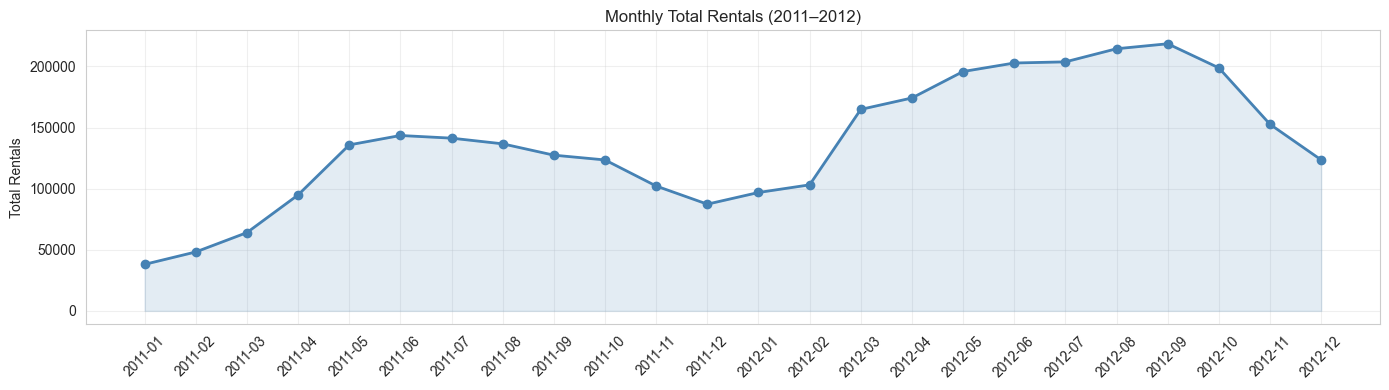

In [15]:
# Total rentals per month across 2011 and 2012
# Shows business growth and seasonal cycles

monthly = df.groupby(['yr', 'mnth'])['cnt'].sum().reset_index()
monthly['period'] = (monthly['yr'].astype(int).astype(str) + '-' +
                     monthly['mnth'].astype(int).astype(str).str.zfill(2))

plt.figure(figsize=(14, 4))
plt.plot(range(len(monthly)), monthly['cnt'], marker='o', color='steelblue', linewidth=2)
plt.fill_between(range(len(monthly)), monthly['cnt'], alpha=0.15, color='steelblue')
plt.xticks(range(len(monthly)), monthly['period'], rotation=45)
plt.title('Monthly Total Rentals (2011–2012)')
plt.ylabel('Total Rentals')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

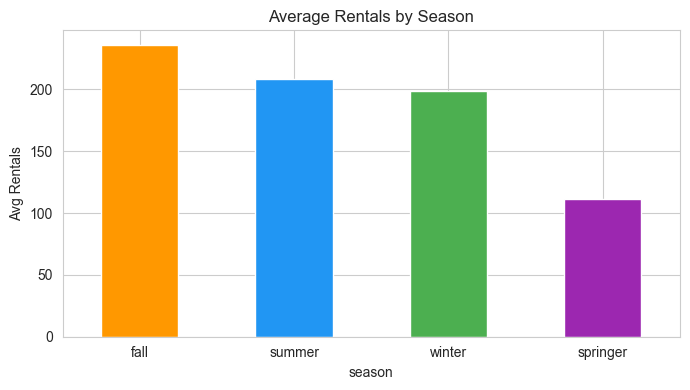

In [16]:
# Average rentals by season — Fall tends to be the best season for biking
season_avg = df.groupby('season')['cnt'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
season_avg.plot(kind='bar', color=['#FF9800', '#2196F3', '#4CAF50', '#9C27B0'], edgecolor='white')
plt.title('Average Rentals by Season')
plt.ylabel('Avg Rentals')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

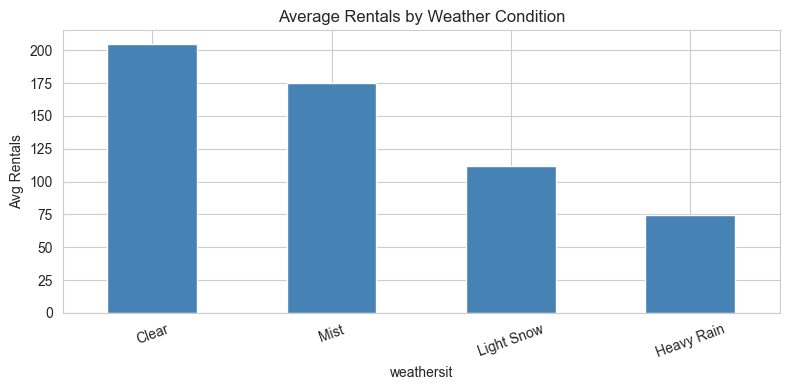

In [17]:
# Average rentals by weather situation
# Clear > Misty > Light Rain — bad weather = fewer riders
weather_avg = df.groupby('weathersit')['cnt'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
weather_avg.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Average Rentals by Weather Condition')
plt.ylabel('Avg Rentals')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

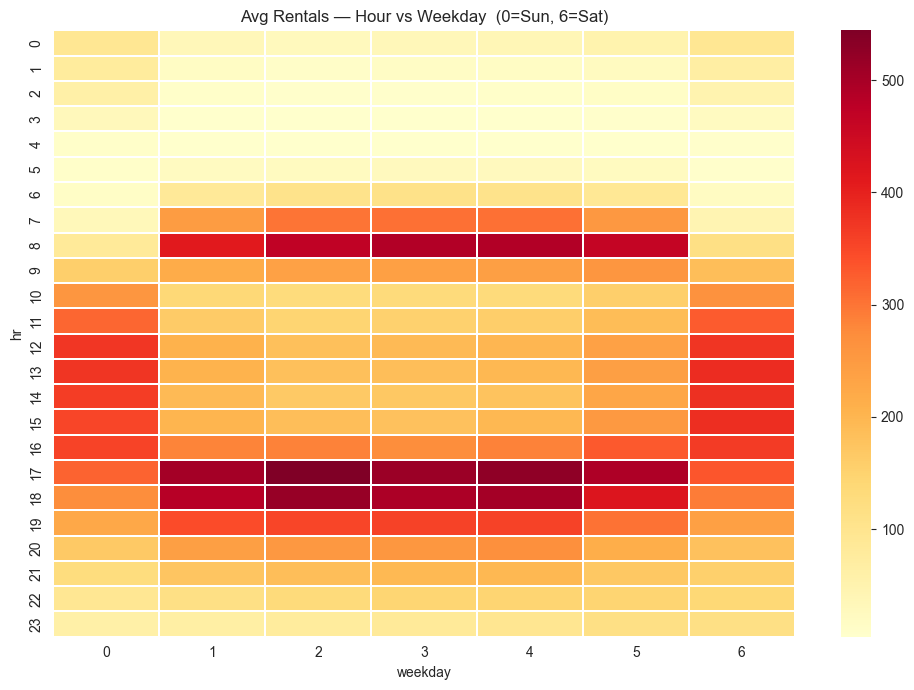

In [18]:
# Hour vs Weekday heatmap — darkest cells = peak demand
# 0 = Sunday, 6 = Saturday
pivot = df.pivot_table(values='cnt', index='hr', columns='weekday', aggfunc='mean')

plt.figure(figsize=(10, 7))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3)
plt.title('Avg Rentals — Hour vs Weekday  (0=Sun, 6=Sat)')
plt.tight_layout()
plt.show()

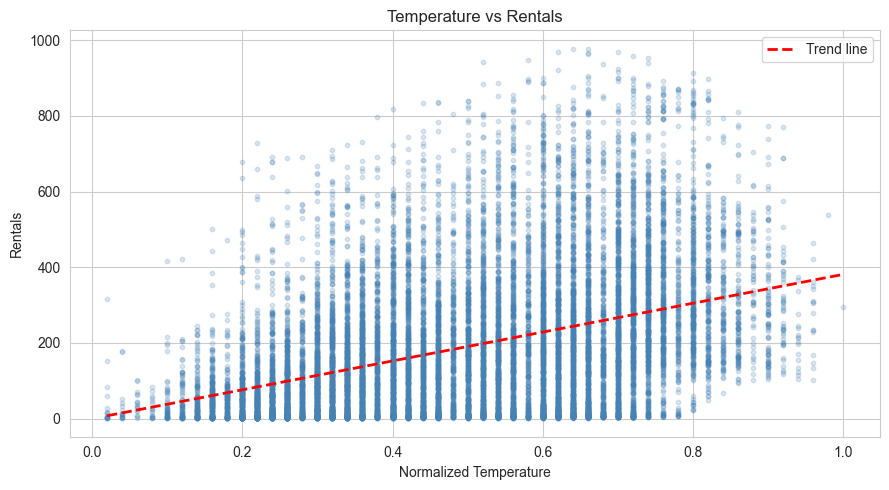

In [19]:
# Temperature vs Rentals scatter plot with a trend line
# We filter out any NaN/inf before fitting — np.polyfit crashes on NaN input

mask = np.isfinite(df['temp']) & np.isfinite(df['cnt'])
temp_clean = df['temp'][mask]
cnt_clean  = df['cnt'][mask]

plt.figure(figsize=(9, 5))
plt.scatter(temp_clean, cnt_clean, alpha=0.2, s=10, color='steelblue')

# Fit a straight line (degree=1 polynomial) to show the overall trend
z = np.polyfit(temp_clean, cnt_clean, 1)
p = np.poly1d(z)
x_line = np.linspace(temp_clean.min(), temp_clean.max(), 100)
plt.plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend line')

plt.title('Temperature vs Rentals')
plt.xlabel('Normalized Temperature')
plt.ylabel('Rentals')
plt.legend()
plt.tight_layout()
plt.show()

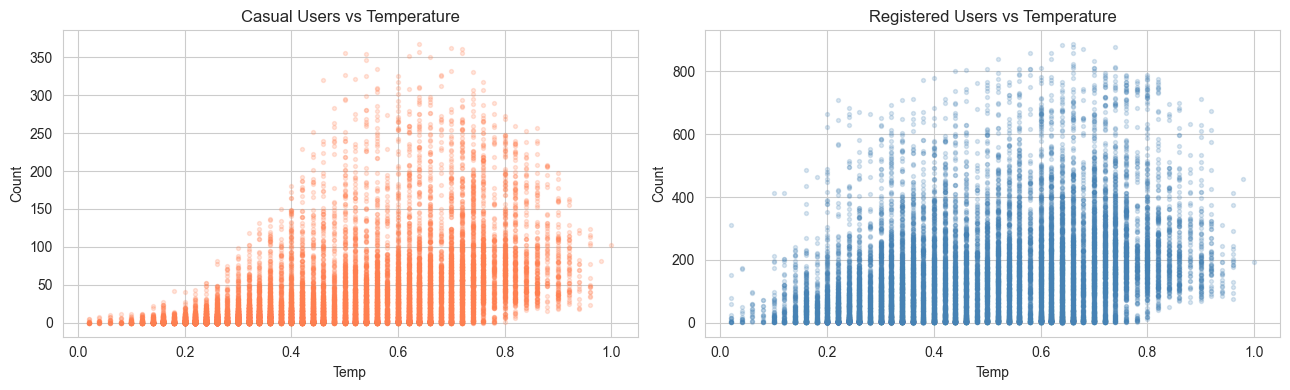

In [20]:
# Casual vs Registered users vs Temperature
# Casual users are more sensitive to temperature (leisure riders)
# Registered users show higher base demand regardless of temperature

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(df['temp'], df['casual'], alpha=0.2, s=8, color='coral')
axes[0].set_title('Casual Users vs Temperature')
axes[0].set_xlabel('Temp')
axes[0].set_ylabel('Count')

axes[1].scatter(df['temp'], df['registered'], alpha=0.2, s=8, color='steelblue')
axes[1].set_title('Registered Users vs Temperature')
axes[1].set_xlabel('Temp')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Key Findings from EDA

| Finding | Detail |
|---|---|
| **Hour is the strongest predictor** | Peaks at 8am and 5–6pm on working days (commuters) |
| **Weekend pattern is different** | Single broad midday peak — leisure/recreational use |
| **Season matters** | Fall > Summer > Spring > Winter |
| **Weather impact** | Clear weather has ~2× more rentals vs Light Rain/Snow |
| **Temperature** | Strong positive correlation with cnt |
| **Year-over-year growth** | 2012 significantly outperformed 2011 |
| **User types** | Registered users dominate; casual users spike on weekends |

## Step 6 — Feature Engineering

Transform the cleaned data into model-ready features:
- Create new useful columns (`day_of_year`, `is_weekend`)
- One-hot encode categorical columns (turn text labels into 0/1 numbers)
- Drop columns not useful for modelling

In [21]:
# Work on a copy so the original df stays intact for reference
df_model = df.copy()

# New feature: day within the year (1–365) — captures annual seasonality
df_model['day_of_year'] = df_model['dteday'].dt.dayofyear

# New feature: is this a weekend? (weekday 0=Sun, 6=Sat)
df_model['is_weekend'] = df_model['weekday'].isin([0, 6]).astype(int)

# One-hot encode categorical columns
# drop_first=True removes one dummy per group to avoid multicollinearity
cat_cols = ['season', 'weathersit', 'workingday', 'holiday']
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# Drop columns that are not useful as model features:
# - 'instant': just a row index
# - 'dteday': already encoded as day_of_year, yr, mnth
# - 'casual' and 'registered': sub-components of cnt (would cause data leakage)
df_model.drop(columns=['instant', 'dteday', 'casual', 'registered'], inplace=True)

print(f"Shape after feature engineering: {df_model.shape}")
df_model.head(3)

Shape after feature engineering: (17379, 19)


,yr,mnth,hr,weekday,temp,atemp,hum,windspeed,cnt,day_of_year,is_weekend,season_springer,season_summer,season_winter,weathersit_Heavy Rain,weathersit_Light Snow,weathersit_Mist,workingday_Working Day,holiday_Yes
0,2011.0,1.0,0,6,0.24,0.2879,0.81,0.0,16,1,1,True,False,False,False,False,False,False,False
1,2011.0,1.0,1,6,0.22,0.2727,0.80,0.0,40,1,1,True,False,False,False,False,False,False,False
2,2011.0,1.0,2,6,0.22,0.2727,0.63,0.0,32,1,1,True,False,False,False,False,False,False,False


## Step 7 — Scale Features & Train/Test Split

In [22]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_model.drop(columns=['cnt'])
y = df_model['cnt']

# Confirm no NaN values exist before training — this is essential
assert X.isnull().sum().sum() == 0, "X still contains NaN values!"
assert y.isnull().sum() == 0, "y still contains NaN values!"
print("No NaN values in X or y — safe to train.")

# Scale continuous weather features to [0, 1] range
# Tree-based models don't strictly need scaling, but it's good practice
scaler = MinMaxScaler()
num_features = ['temp', 'atemp', 'hum', 'windspeed']
X = X.copy()                                             # avoid SettingWithCopyWarning
X[num_features] = scaler.fit_transform(X[num_features])

# Split: 80% training, 20% testing
# random_state=42 ensures the same split every time you run the notebook
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set:  {X_train.shape}")
print(f"Test set:      {X_test.shape}")

No NaN values in X or y — safe to train.
Training set:  (13903, 18)
Test set:      (3476, 18)


## Step 8 — Train Baseline Models

We'll train three models and compare their performance:
1. **Decision Tree** — simple, interpretable, prone to overfitting
2. **Random Forest** — many trees averaged together, much more stable
3. **Gradient Boosting** — trees built sequentially to correct errors, very powerful

**Metrics:**
- **MAE** (Mean Absolute Error) — average prediction error in rental units
- **RMSE** (Root Mean Squared Error) — penalises large errors more heavily
- **R²** — % of variance explained; 1.0 = perfect, 0 = no better than predicting the mean

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dictionary to store results from all models for comparison later
results = {}

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    """Train model, predict on test set, print and store metrics."""
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)

    print(f"{name:<25}  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}")

    # Save everything for later comparison and plotting
    results[name] = {
        'MAE': round(mae, 2), 'RMSE': round(rmse, 2),
        'R2': round(r2, 4), 'model': model, 'pred': pred
    }

In [24]:
# --- Model 1: Decision Tree ---
# Splits data into branches based on feature thresholds.
# Without limits it memorises training data (overfits), so test performance is weaker.

from sklearn.tree import DecisionTreeRegressor

evaluate('Decision Tree',
         DecisionTreeRegressor(random_state=42),
         X_train, y_train, X_test, y_test)

Decision Tree              MAE=34.08  RMSE=59.03  R²=0.8900


In [25]:
# --- Model 2: Random Forest ---
# Builds 100 decision trees on random subsets of data and averages their predictions.
# Reduces variance vs a single tree → better generalisation.
# n_jobs=-1 uses all CPU cores to train faster.

from sklearn.ensemble import RandomForestRegressor

evaluate('Random Forest',
         RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
         X_train, y_train, X_test, y_test)

Random Forest              MAE=24.22  RMSE=40.98  R²=0.9470


In [26]:
# --- Model 3: Gradient Boosting ---
# Each new tree is trained to fix the mistakes of the previous trees.
# learning_rate=0.1 controls how much each tree contributes (smaller = more careful).
# max_depth=5 limits tree complexity to prevent overfitting.

from sklearn.ensemble import GradientBoostingRegressor

evaluate('Gradient Boosting',
         GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                   max_depth=5, random_state=42),
         X_train, y_train, X_test, y_test)

Gradient Boosting          MAE=25.06  RMSE=39.68  R²=0.9503


## Step 9 — Hyperparameter Tuning

Baseline models use default settings. Tuning finds better settings automatically.

- **GridSearchCV** — tries every combination in the grid (thorough but slow)
- **RandomizedSearchCV** — tries a random sample of combinations (faster, nearly as good)
- **cv=5** — 5-fold cross-validation: splits training data into 5 parts, trains on 4 and validates on 1, rotates 5 times

In [27]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Decision Tree tuning — GridSearch because the grid is small enough
dt_params = {
    'max_depth':        [5, 10, 15, 20, None],  # None = unlimited depth
    'min_samples_split': [2, 5, 10],             # min samples needed to split a node
    'min_samples_leaf':  [1, 2, 4]               # min samples required at a leaf node
}

dt_gs = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params,
    cv=5,
    scoring='neg_root_mean_squared_error',  # negative because sklearn minimises
    n_jobs=-1
)
dt_gs.fit(X_train, y_train)

print('Best DT params:', dt_gs.best_params_)
evaluate('DT  (Tuned)', dt_gs.best_estimator_, X_train, y_train, X_test, y_test)

Best DT params: {'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10}
DT  (Tuned)                MAE=31.66  RMSE=54.35  R²=0.9067


In [28]:
# Random Forest tuning — RandomizedSearch because the search space is large
rf_params = {
    'n_estimators':     [100, 200, 300],       # number of trees
    'max_depth':        [10, 20, 30, None],    # max depth of each tree
    'min_samples_split': [2, 5, 10],
    'max_features':     ['sqrt', 'log2']       # how many features to consider per split
}

rf_rs = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    n_iter=20,                                 # try 20 random combinations
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)
rf_rs.fit(X_train, y_train)

print('Best RF params:', rf_rs.best_params_)
evaluate('RF  (Tuned)', rf_rs.best_estimator_, X_train, y_train, X_test, y_test)

Best RF params: {'n_estimators': 100, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 20}


RF  (Tuned)                MAE=38.01  RMSE=58.13  R²=0.8933


In [29]:
# Gradient Boosting tuning
gb_params = {
    'n_estimators':  [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth':     [3, 5, 7],
    'subsample':     [0.7, 0.8, 1.0]   # fraction of samples used per tree (< 1 adds randomness)
}

gb_rs = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    n_iter=20,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)
gb_rs.fit(X_train, y_train)

print('Best GB params:', gb_rs.best_params_)
evaluate('GB  (Tuned)', gb_rs.best_estimator_, X_train, y_train, X_test, y_test)

Best GB params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1}


GB  (Tuned)                MAE=21.70  RMSE=35.69  R²=0.9598


## Step 8b — Additional Models: Ridge Regression, Extra Trees, XGBoost

Three more model families are added to broaden the comparison:
- **Ridge Regression** — linear model with L2 regularisation; interpretable baseline
- **Extra Trees** — like Random Forest but uses fully random split thresholds; often faster
- **XGBoost** — industry-grade gradient boosting with built-in L1/L2 regularisation

> Install XGBoost if needed: `pip install xgboost`

In [30]:
# --- Model 4: Ridge Regression ---
# Linear model; coefficients are penalised by L2 norm (alpha controls strength).
# Fast to train and fully interpretable — useful as a linear baseline.

from sklearn.linear_model import Ridge

evaluate('Ridge Regression',
         Ridge(alpha=1.0),
         X_train, y_train, X_test, y_test)

Ridge Regression           MAE=103.72  RMSE=137.88  R²=0.3996


In [31]:
# Ridge tuning — only one hyperparameter (alpha), so GridSearch is cheap
ridge_gs = GridSearchCV(
    Ridge(),
    {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]},
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
ridge_gs.fit(X_train, y_train)
print('Best Ridge params:', ridge_gs.best_params_)
evaluate('Ridge (Tuned)', ridge_gs.best_estimator_, X_train, y_train, X_test, y_test)

Best Ridge params: {'alpha': 1.0}
Ridge (Tuned)              MAE=103.72  RMSE=137.88  R²=0.3996


In [32]:
# --- Model 5: Extra Trees Regressor ---
# Each tree chooses split thresholds completely at random (vs best-of-K in RF).
# Higher randomisation reduces variance; can outperform Random Forest on noisy data.

from sklearn.ensemble import ExtraTreesRegressor

evaluate('Extra Trees',
         ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
         X_train, y_train, X_test, y_test)

Extra Trees                MAE=23.86  RMSE=40.27  R²=0.9488


In [33]:
# Extra Trees tuning
et_rs = RandomizedSearchCV(
    ExtraTreesRegressor(random_state=42, n_jobs=-1),
    {
        'n_estimators':      [100, 200, 300],
        'max_depth':         [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'max_features':      ['sqrt', 'log2'],
    },
    n_iter=15, cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1
)
et_rs.fit(X_train, y_train)
print('Best ET params:', et_rs.best_params_)
evaluate('Extra Trees (Tuned)', et_rs.best_estimator_, X_train, y_train, X_test, y_test)

Best ET params: {'n_estimators': 300, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': 30}


Extra Trees (Tuned)        MAE=46.55  RMSE=69.73  R²=0.8465


In [34]:
# --- Model 6: XGBoost ---
# Gradient boosting with built-in L1/L2 regularisation (reg_alpha / reg_lambda).
# Install: pip install xgboost

try:
    from xgboost import XGBRegressor
    evaluate('XGBoost',
             XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
             X_train, y_train, X_test, y_test)
except ImportError:
    print('XGBoost not installed. Run: pip install xgboost')

XGBoost                    MAE=23.84  RMSE=37.94  R²=0.9545


In [35]:
# XGBoost tuning
try:
    from xgboost import XGBRegressor
    xgb_rs = RandomizedSearchCV(
        XGBRegressor(random_state=42, verbosity=0),
        {
            'n_estimators':     [100, 200, 300],
            'learning_rate':    [0.05, 0.1, 0.2],
            'max_depth':        [3, 5, 7],
            'subsample':        [0.7, 0.8, 1.0],
            'colsample_bytree': [0.7, 0.8, 1.0],
            'reg_alpha':        [0, 0.1, 0.5],
            'reg_lambda':       [1.0, 1.5, 2.0],
        },
        n_iter=20, cv=5,
        scoring='neg_root_mean_squared_error',
        random_state=42, n_jobs=-1
    )
    xgb_rs.fit(X_train, y_train)
    print('Best XGBoost params:', xgb_rs.best_params_)
    evaluate('XGBoost (Tuned)', xgb_rs.best_estimator_, X_train, y_train, X_test, y_test)
except ImportError:
    print('XGBoost not installed. Run: pip install xgboost')

Best XGBoost params: {'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


XGBoost (Tuned)            MAE=21.95  RMSE=35.04  R²=0.9612


## Step 10 — Model Comparison

In [36]:
# Build a summary table of all models sorted by RMSE (lower is better)
comparison = pd.DataFrame(
    [{'Model': k, 'MAE': v['MAE'], 'RMSE': v['RMSE'], 'R²': v['R2']}
     for k, v in results.items()]
).sort_values('RMSE').reset_index(drop=True)

print("Model comparison (sorted by RMSE — lower is better):")
comparison

Model comparison (sorted by RMSE — lower is better):


,Model,MAE,RMSE,R²
0,XGBoost (Tuned),21.95,35.04,0.9612
1,GB (Tuned),21.70,35.69,0.9598
2,XGBoost,23.84,37.94,0.9545
3,Gradient Boosting,25.06,39.68,0.9503
4,Extra Trees,23.86,40.27,0.9488
5,Random Forest,24.22,40.98,0.9470
6,DT (Tuned),31.66,54.35,0.9067
7,RF (Tuned),38.01,58.13,0.8933
8,Decision Tree,34.08,59.03,0.8900
9,Extra Trees (Tuned),46.55,69.73,0.8465


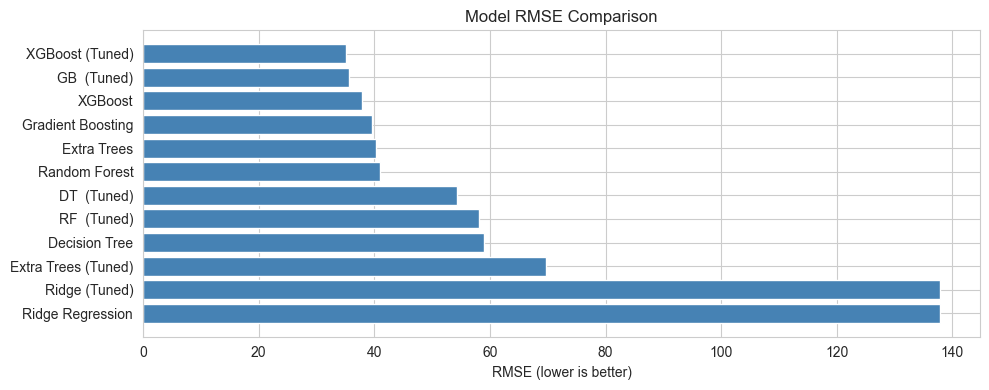

In [37]:
# Visual comparison of RMSE across all models
plt.figure(figsize=(10, 4))
plt.barh(comparison['Model'], comparison['RMSE'], color='steelblue', edgecolor='white')
plt.xlabel('RMSE (lower is better)')
plt.title('Model RMSE Comparison')
plt.gca().invert_yaxis()   # best model at top
plt.tight_layout()
plt.show()

## Step 11 — Final Evaluation of Best Model

In [38]:
# Automatically pick the model with the lowest RMSE
best_name  = min(results, key=lambda k: results[k]['RMSE'])
best_model = results[best_name]['model']
best_pred  = results[best_name]['pred']

print(f"Best model: {best_name}")
print(f"  MAE  = {results[best_name]['MAE']}")
print(f"  RMSE = {results[best_name]['RMSE']}")
print(f"  R²   = {results[best_name]['R2']}")

Best model: XGBoost (Tuned)
  MAE  = 21.95
  RMSE = 35.04
  R²   = 0.9612


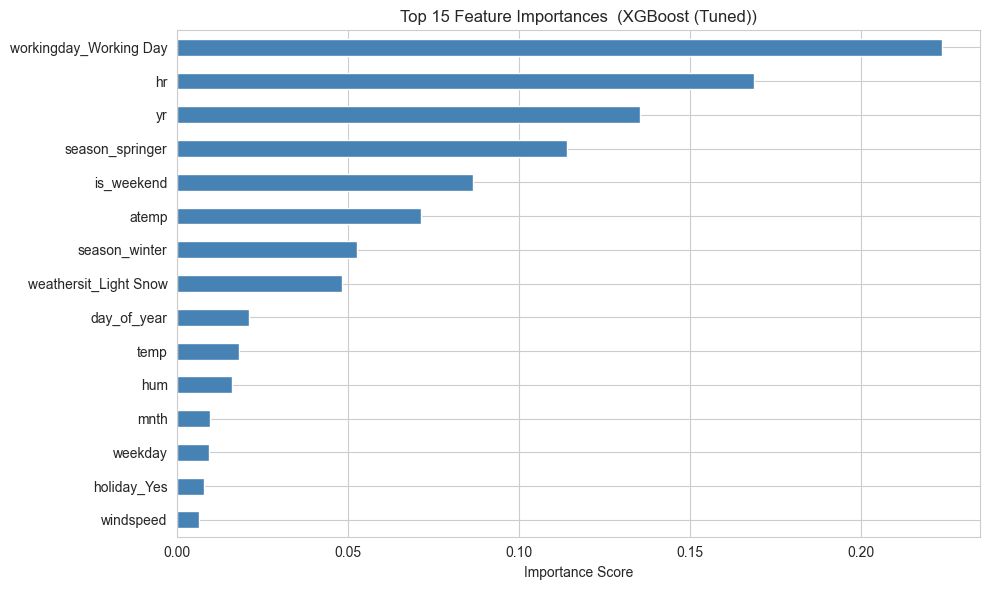

In [39]:
# Feature importance — which inputs matter most for predictions?
# Higher bar = that feature contributes more to the model's decisions

feat_imp = pd.Series(
    best_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh', color='steelblue', edgecolor='white')
plt.gca().invert_yaxis()
plt.title(f'Top 15 Feature Importances  ({best_name})')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

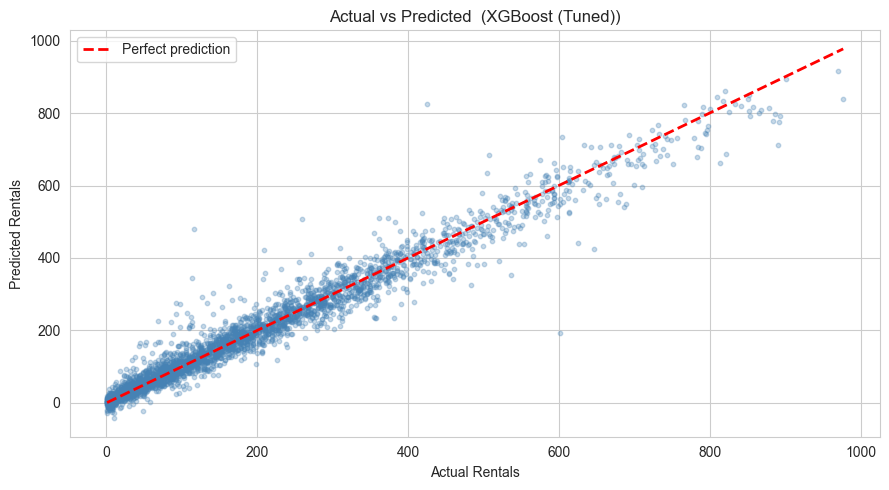

In [40]:
# Actual vs Predicted scatter plot
# Perfect model = all points on the red diagonal line
# Points scattered around it = typical prediction error

plt.figure(figsize=(9, 5))
plt.scatter(y_test, best_pred, alpha=0.3, s=10, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.title(f'Actual vs Predicted  ({best_name})')
plt.xlabel('Actual Rentals')
plt.ylabel('Predicted Rentals')
plt.legend()
plt.tight_layout()
plt.show()

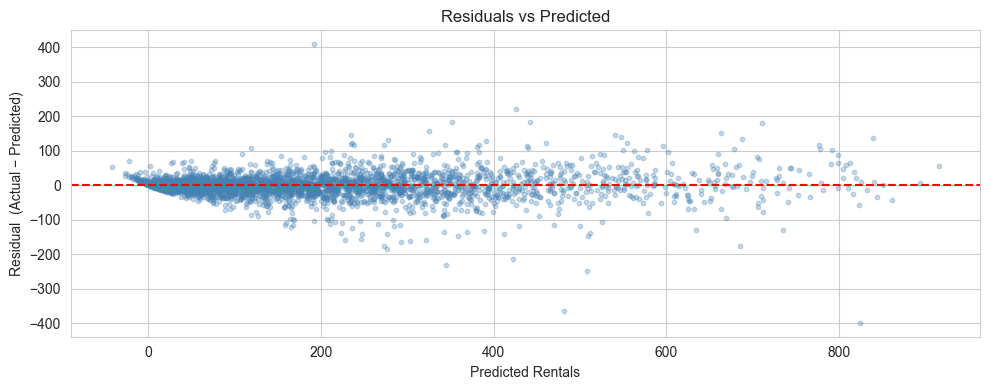

In [41]:
# Residuals plot: error = actual - predicted
# Good model → residuals randomly scattered around 0 (no systematic bias)
# A pattern here would indicate the model is missing something

residuals = y_test.values - best_pred

plt.figure(figsize=(10, 4))
plt.scatter(best_pred, residuals, alpha=0.3, s=10, color='steelblue')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residuals vs Predicted')
plt.xlabel('Predicted Rentals')
plt.ylabel('Residual  (Actual − Predicted)')
plt.tight_layout()
plt.show()

## Step 12 — Save the Best Model

In [42]:
import joblib, json

# Save best model and scaler
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler,     'scaler.pkl')

# Export all model metrics so the Streamlit app can load them
results_export = {
    k: {'MAE': v['MAE'], 'RMSE': v['RMSE'], 'R2': v['R2']}
    for k, v in results.items()
}
with open('model_results.json', 'w') as f:
    json.dump(results_export, f, indent=2)

print(f"Saved '{best_name}' as best_model.pkl")
print('Saved scaler as scaler.pkl')
print('Saved model_results.json')
print()
print('To reload later:')
print('  model  = joblib.load("best_model.pkl")')
print('  scaler = joblib.load("scaler.pkl")')

Saved 'XGBoost (Tuned)' as best_model.pkl
Saved scaler as scaler.pkl
Saved model_results.json

To reload later:
  model  = joblib.load("best_model.pkl")
  scaler = joblib.load("scaler.pkl")
